In [11]:
!pip install kaggle


In [12]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 66 bytes


In [13]:

!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

!unzip skin-cancer-mnist-ham10000.zip -d skin-cancer-mnist-ham10000

Streaming output truncated to the last 5000 lines.
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029325.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: skin-cancer-mnist-ham10000/ham1000

In [14]:

import pandas as pd
import os

# Dataset path
image_dir = '/content/skin-cancer-mnist-ham10000/'

# Metadata file path
labels_file = os.path.join(image_dir, 'HAM10000_metadata.csv')

# Load CSV file
labels_df = pd.read_csv(labels_file)
# Check dataset loaded correctly
print(labels_df.head())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [15]:
# Print dataset information
print("Dataset Information:")
print(labels_df.info())

# Get the number of unique classes
num_classes = labels_df['dx'].nunique()
print(f"\nNumber of Classes: {num_classes}")

# Get the class names (abbreviated)
class_names_short = labels_df['dx'].unique()
print("Class Names (Abbreviated):", class_names_short)

# Mapping of short names to full names
class_name_mapping = {
    'bcc': 'basal cell carcinoma',
    'nv': 'melanocytic nevi',
    'mel': 'melanoma',
    'bkl': 'benign keratosis-like lesions',
    'vasc': 'vascular lesions',
    'df': 'dermatofibroma',
    'akiec': 'actinic keratoses & intraepithelial carcinoma'
}

print("\nClass Names (Full):")
for short_name in class_names_short:
    full_name = class_name_mapping.get(short_name, short_name)
    print(f"- {short_name}: {full_name}")

# If you have already run the cell with the LabelEncoder, you can also get class names from it:
# if 'label_encoder' in globals():
#     print("\nClass Names from LabelEncoder:", label_encoder.classes_)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
None

Number of Classes: 7
Class Names (Abbreviated): ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']

Class Names (Full):
- bkl: benign keratosis-like lesions
- nv: melanocytic nevi
- df: dermatofibroma
- mel: melanoma
- vasc: vascular lesions
- bcc: basal cell carcinoma
- akiec: actinic keratoses & intraepithelial carcinoma


In [16]:
!pip install tensorflow

In [17]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths
image_dir = '/content/skin-cancer-mnist-ham10000/'
labels_file = os.path.join(image_dir, 'HAM10000_metadata.csv')

# Load labels
labels_df = pd.read_csv(labels_file)
labels_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [18]:
import pandas as pd
import os

# Define paths
image_dir = '/content/skin-cancer-mnist-ham10000/'
labels_file = os.path.join(image_dir, 'HAM10000_metadata.csv')

# Load labels
labels_df = pd.read_csv(labels_file)
print("labels_df loaded successfully.")

labels_df loaded successfully.


In [19]:

image_paths = [os.path.join(image_dir, 'HAM10000_images_part_1', img_id + '.jpg')
               for img_id in labels_df['image_id']]
missing_images = [img_path for img_path in image_paths if not os.path.exists(img_path)]

for i in range(len(missing_images)):
    img_id = os.path.basename(missing_images[i]).replace('.jpg', '')
    image_paths[image_paths.index(missing_images[i])] = os.path.join(image_dir, 'HAM10000_images_part_2', img_id + '.jpg')

img_width, img_height = 128, 128
images = []
for img_path in image_paths:
    img = load_img(img_path, target_size=(img_width, img_height))
    img_array = img_to_array(img)
    images.append(img_array)

images = np.array(images)
labels = labels_df['dx'].values

images = images / 255.0

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)


Images shape: (10015, 128, 128, 3)
Labels shape: (10015,)


In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels_encoded,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8012, 128, 128, 3)
X_test shape: (2003, 128, 128, 3)
y_train shape: (8012,)
y_test shape: (2003,)


**Reasoning**:
Apply data augmentation to the training set.



In [21]:

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(X_train)

print("Data augmentation applied to X_train.")

Data augmentation applied to X_train.


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
num_classes = len(np.unique(y_train))
model = Sequential([
    Input(shape=(img_width, img_height, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Train the model
epochs = 10
batch_size = 32

history = model.fit(datagen.flow(X_train, y_train, batch_size=batch_size),
                    epochs=epochs,
                    validation_data=(X_test, y_test))

# Save trained model
model.save("skin_cancer_model.h5")

# Save label encoder
import pickle
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 47s 162ms/step - accuracy: 0.6666 - loss: 1.0416 - val_accuracy: 0.6695 - val_loss: 1.0123
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 35s 140ms/step - accuracy: 0.6661 - loss: 0.9576 - val_accuracy: 0.6675 - val_loss: 0.8987
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 138ms/step - accuracy: 0.6696 - loss: 0.9059 - val_accuracy: 0.6765 - val_loss: 0.8518
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.6802 - loss: 0.8565 - val_accuracy: 0.6810 - val_loss: 0.8322
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 35s 140ms/step - accuracy: 0.6935 - loss: 0.8220 - val_accuracy: 0.6975 - val_loss: 0.7868
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 36s 141ms/step - accuracy: 0.7054 - loss: 0.7884 - val_accuracy: 0.7249 - val_loss: 0.7473
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 35s 139ms/step - accuracy: 0.7078 - loss: 0.7729 - val_accuracy: 0.6980 - val_loss: 0.7966
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 33s 133ms/step - accuracy: 0.7133 - loss: 0

In [24]:
from google.colab import files
files.download("skin_cancer_model.h5")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print(f"Test Accuracy: {accuracy:.2%}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7369 - loss: 0.7179
Test Loss: 0.7178558707237244
Test Accuracy: 73.69%


Please enter the path to the image: /content/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024575.jpg


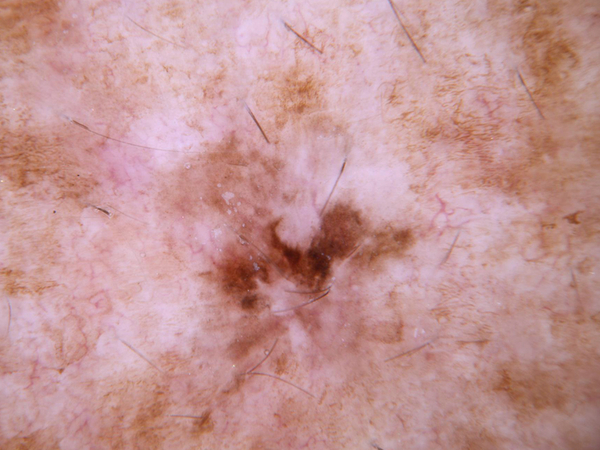

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
skin disease found: melanocytic nevi
Probability of Predicted Class: 0.3348
Risk Level: Low
All Class Probabilities:
- actinic keratoses & intraepithelial carcinoma: 0.1441
- basal cell carcinoma: 0.2601
- benign keratosis-like lesions: 0.0302
- dermatofibroma: 0.0067
- melanoma: 0.2139
- melanocytic nevi: 0.3348
- vascular lesions: 0.0102


In [27]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
from IPython.display import display
from PIL import Image

def predict_skin_disease(image_path, model, label_encoder, img_width, img_height):
    """
    Predicts the skin disease from an input image.

    Args:
        image_path (str): Path to the input image.
        model (tf.keras.Model): Trained deep learning model.
        label_encoder (sklearn.preprocessing.LabelEncoder): Label encoder used for the labels.
        img_width (int): Width of the input images for the model.
        img_height (int): Height of the input images for the model.

    Returns:
        tuple: A tuple containing the predicted class name and the prediction probabilities.
    """
    img = load_img(image_path, target_size=(img_width, img_height))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0
    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions)
    predicted_class_probability = predictions[0][predicted_class_index]
    predicted_class_name_short = label_encoder.inverse_transform([predicted_class_index])[0]
    class_name_mapping = {
        'bcc': 'basal cell carcinoma',
        'nv': 'melanocytic nevi',
        'mel': 'melanoma',
        'bkl': 'benign keratosis-like lesions',
        'vasc': 'vascular lesions',
        'df': 'dermatofibroma',
        'akiec': 'actinic keratoses & intraepithelial carcinoma'
    }
    predicted_class_name_full = class_name_mapping.get(predicted_class_name_short, predicted_class_name_short)


    return predicted_class_name_full, predicted_class_probability, predictions[0], class_name_mapping

def assess_risk(skin_disease_name):
    """
    Provides a simplified, rule-based risk assessment for skin diseases.
    This is not a substitute for medical advice.
    """
    if skin_disease_name in ['melanoma', 'basal cell carcinoma', 'actinic keratoses & intraepithelial carcinoma']:
        return "High"
    elif skin_disease_name in ['benign keratosis-like lesions', 'vascular lesions', 'dermatofibroma']:
        return "Moderate"
    elif skin_disease_name in ['melanocytic nevi']:
        return "Low"
    else:
        return "Unknown"


image_path_input = input("Please enter the path to the image: ")


try:
    img_display = Image.open(image_path_input)
    display(img_display)
except FileNotFoundError:
    print(f"Error: Image file not found at {image_path_input}")
except Exception as e:
    print(f"Error displaying image: {e}")


predicted_class, probability, all_probabilities, class_name_mapping = predict_skin_disease(
    image_path_input, model, label_encoder, img_width, img_height
)

print(f"skin disease found: {predicted_class}")
print(f"Probability of Predicted Class: {probability:.4f}")


risk_level = assess_risk(predicted_class)
print(f"Risk Level: {risk_level}")

print("All Class Probabilities:")
for i, prob in enumerate(all_probabilities):
    class_name_short = label_encoder.inverse_transform([i])[0]
    class_name_full = class_name_mapping.get(class_name_short, class_name_short)
    print(f"- {class_name_full}: {prob:.4f}")

Please enter the path to the image: /content/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024579.jpg


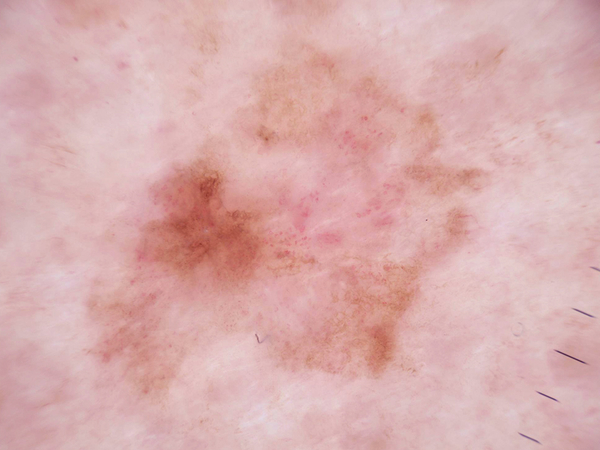

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
skin disease found: basal cell carcinoma
Probability of Predicted Class: 0.4319
Risk Level: High
All Class Probabilities:
- actinic keratoses & intraepithelial carcinoma: 0.2192
- basal cell carcinoma: 0.4319
- benign keratosis-like lesions: 0.0643
- dermatofibroma: 0.1123
- melanoma: 0.0376
- melanocytic nevi: 0.1132
- vascular lesions: 0.0216


In [33]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
from IPython.display import display
from PIL import Image

def predict_skin_disease(image_path, model, label_encoder, img_width, img_height):
    """
    Predicts the skin disease from an input image.

    Args:
        image_path (str): Path to the input image.
        model (tf.keras.Model): Trained deep learning model.
        label_encoder (sklearn.preprocessing.LabelEncoder): Label encoder used for the labels.
        img_width (int): Width of the input images for the model.
        img_height (int): Height of the input images for the model.

    Returns:
        tuple: A tuple containing the predicted class name and the prediction probabilities.
    """
    img = load_img(image_path, target_size=(img_width, img_height))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0


    predictions = model.predict(img_array)

    predicted_class_index = np.argmax(predictions)
    predicted_class_probability = predictions[0][predicted_class_index]
    predicted_class_name_short = label_encoder.inverse_transform([predicted_class_index])[0]


    class_name_mapping = {
        'bcc': 'basal cell carcinoma',
        'nv': 'melanocytic nevi',
        'mel': 'melanoma',
        'bkl': 'benign keratosis-like lesions',
        'vasc': 'vascular lesions',
        'df': 'dermatofibroma',
        'akiec': 'actinic keratoses & intraepithelial carcinoma'
    }
    predicted_class_name_full = class_name_mapping.get(predicted_class_name_short, predicted_class_name_short)


    return predicted_class_name_full, predicted_class_probability, predictions[0], class_name_mapping

def assess_risk(skin_disease_name):
    """
    Provides a simplified, rule-based risk assessment for skin diseases.
    This is not a substitute for medical advice.
    """
    if skin_disease_name in ['melanoma', 'basal cell carcinoma', 'actinic keratoses & intraepithelial carcinoma']:
        return "High"
    elif skin_disease_name in ['benign keratosis-like lesions', 'vascular lesions', 'dermatofibroma']:
        return "Moderate"
    elif skin_disease_name in ['melanocytic nevi']:
        return "Low"
    else:
        return "Unknown"


image_path_input = input("Please enter the path to the image: ")


try:
    img_display = Image.open(image_path_input)
    display(img_display)
except FileNotFoundError:
    print(f"Error: Image file not found at {image_path_input}")
except Exception as e:
    print(f"Error displaying image: {e}")


predicted_class, probability, all_probabilities, class_name_mapping = predict_skin_disease(
    image_path_input, model, label_encoder, img_width, img_height
)

print(f"skin disease found: {predicted_class}")
print(f"Probability of Predicted Class: {probability:.4f}")


risk_level = assess_risk(predicted_class)
print(f"Risk Level: {risk_level}")

print("All Class Probabilities:")
for i, prob in enumerate(all_probabilities):
    class_name_short = label_encoder.inverse_transform([i])[0]
    class_name_full = class_name_mapping.get(class_name_short, class_name_short)
    print(f"- {class_name_full}: {prob:.4f}")

In [34]:
# =============================
# Save Model and Label Encoder
# =============================

import joblib
from google.colab import files

# Save trained model
joblib.dump(model, "skin_disease_model.pkl")

# Save label encoder


print("Files saved successfully")

# Download files
files.download("skin_disease_model.pkl")


Files saved successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>